In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
dataset=pd.read_csv("Preprocessed ILPD.csv")
dataset

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.10,187.00,16.0,18,6.8,3.3,0.90,1
1,62,Male,5.3,2.95,481.75,64.0,100,7.5,3.2,0.74,1
2,62,Male,5.3,2.95,481.75,60.0,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.40,182.00,14.0,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.00,195.00,27.0,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.10,481.75,20.0,34,5.9,1.6,0.37,0
579,40,Male,0.6,0.10,98.00,35.0,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.20,245.00,48.0,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.50,184.00,29.0,32,6.8,3.4,1.00,1


In [28]:
def quanqual(dataset):
        quan=[]
        qual=[]
        for columnName in dataset.columns:
            if (dataset[columnName].dtype=='O'):
                qual.append(columnName)
            else:
                quan.append(columnName)
        return quan,qual


In [29]:
quan,qual=quanqual(dataset)

In [30]:
quan

['Age',
 'TB',
 'DB',
 'Alkphos',
 'Sgpt',
 'Sgot',
 'TP',
 'ALB',
 'A/G Ratio',
 'Selector']

In [3]:
dataset.isna().sum()

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Selector     0
dtype: int64

In [4]:
dataset.shape
print('No of rows:',dataset.shape[0])
print('No of columns:',dataset.shape[1])

No of rows: 583
No of columns: 11


C:\Users\Sathish\AppData\Local\Temp\ipykernel_9720\4125711947.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['TP'],hist=True,kde=True,kde_kws={'color':'Green'})


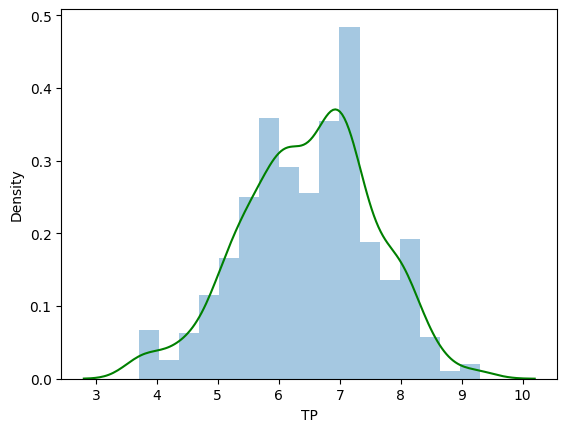

In [5]:
sns.distplot(dataset['TP'],hist=True,kde=True,kde_kws={'color':'Green'})
plt.show()

In [6]:
# Histogram shows the high repeatation, from the graph the high repeatation of TP value between 6.5 to 7.5

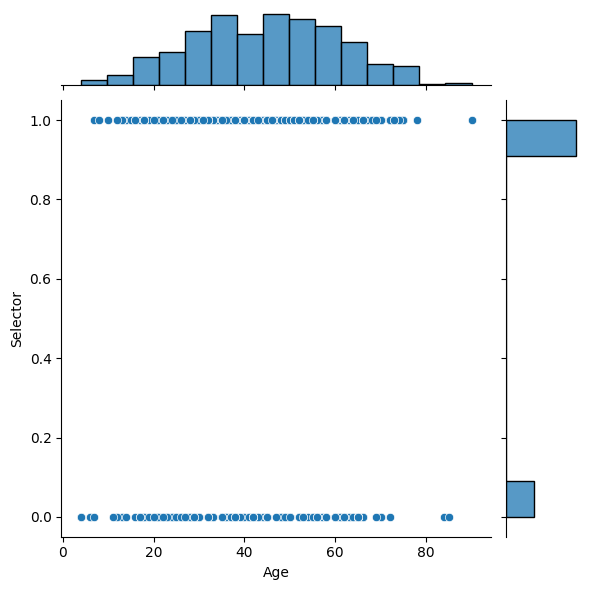

In [7]:
#jointplot shows both scattered and histogram.

sns.jointplot(x='Age',y='Selector',data=dataset)
plt.show()

In [8]:
# The graph shows liver disorder person is more than no liver disorder person and the repeated age between 35 to 45 and 45 to 60.

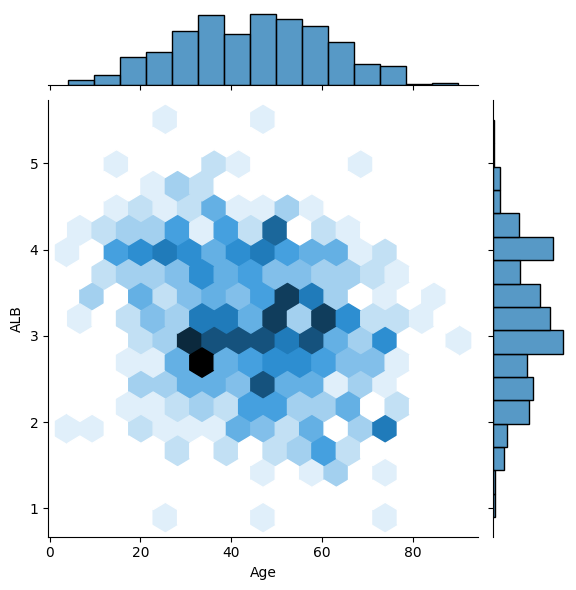

In [9]:
sns.jointplot(x="Age",y="ALB",data=dataset,kind='hex')
plt.show()

In [10]:
# The dark color hexagon shows the highly repeated, so The patient's Age between 30 to 35 has ALB value between 2.5 and 3.

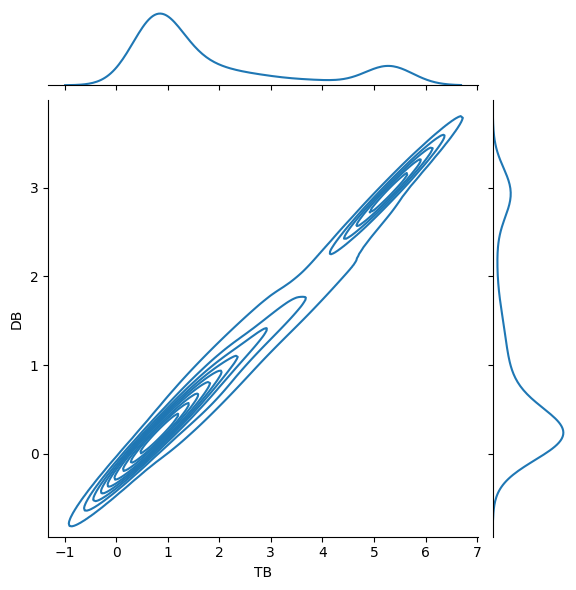

In [11]:
sns.jointplot(x='TB',y='DB',data=dataset,kind='kde')
plt.show()

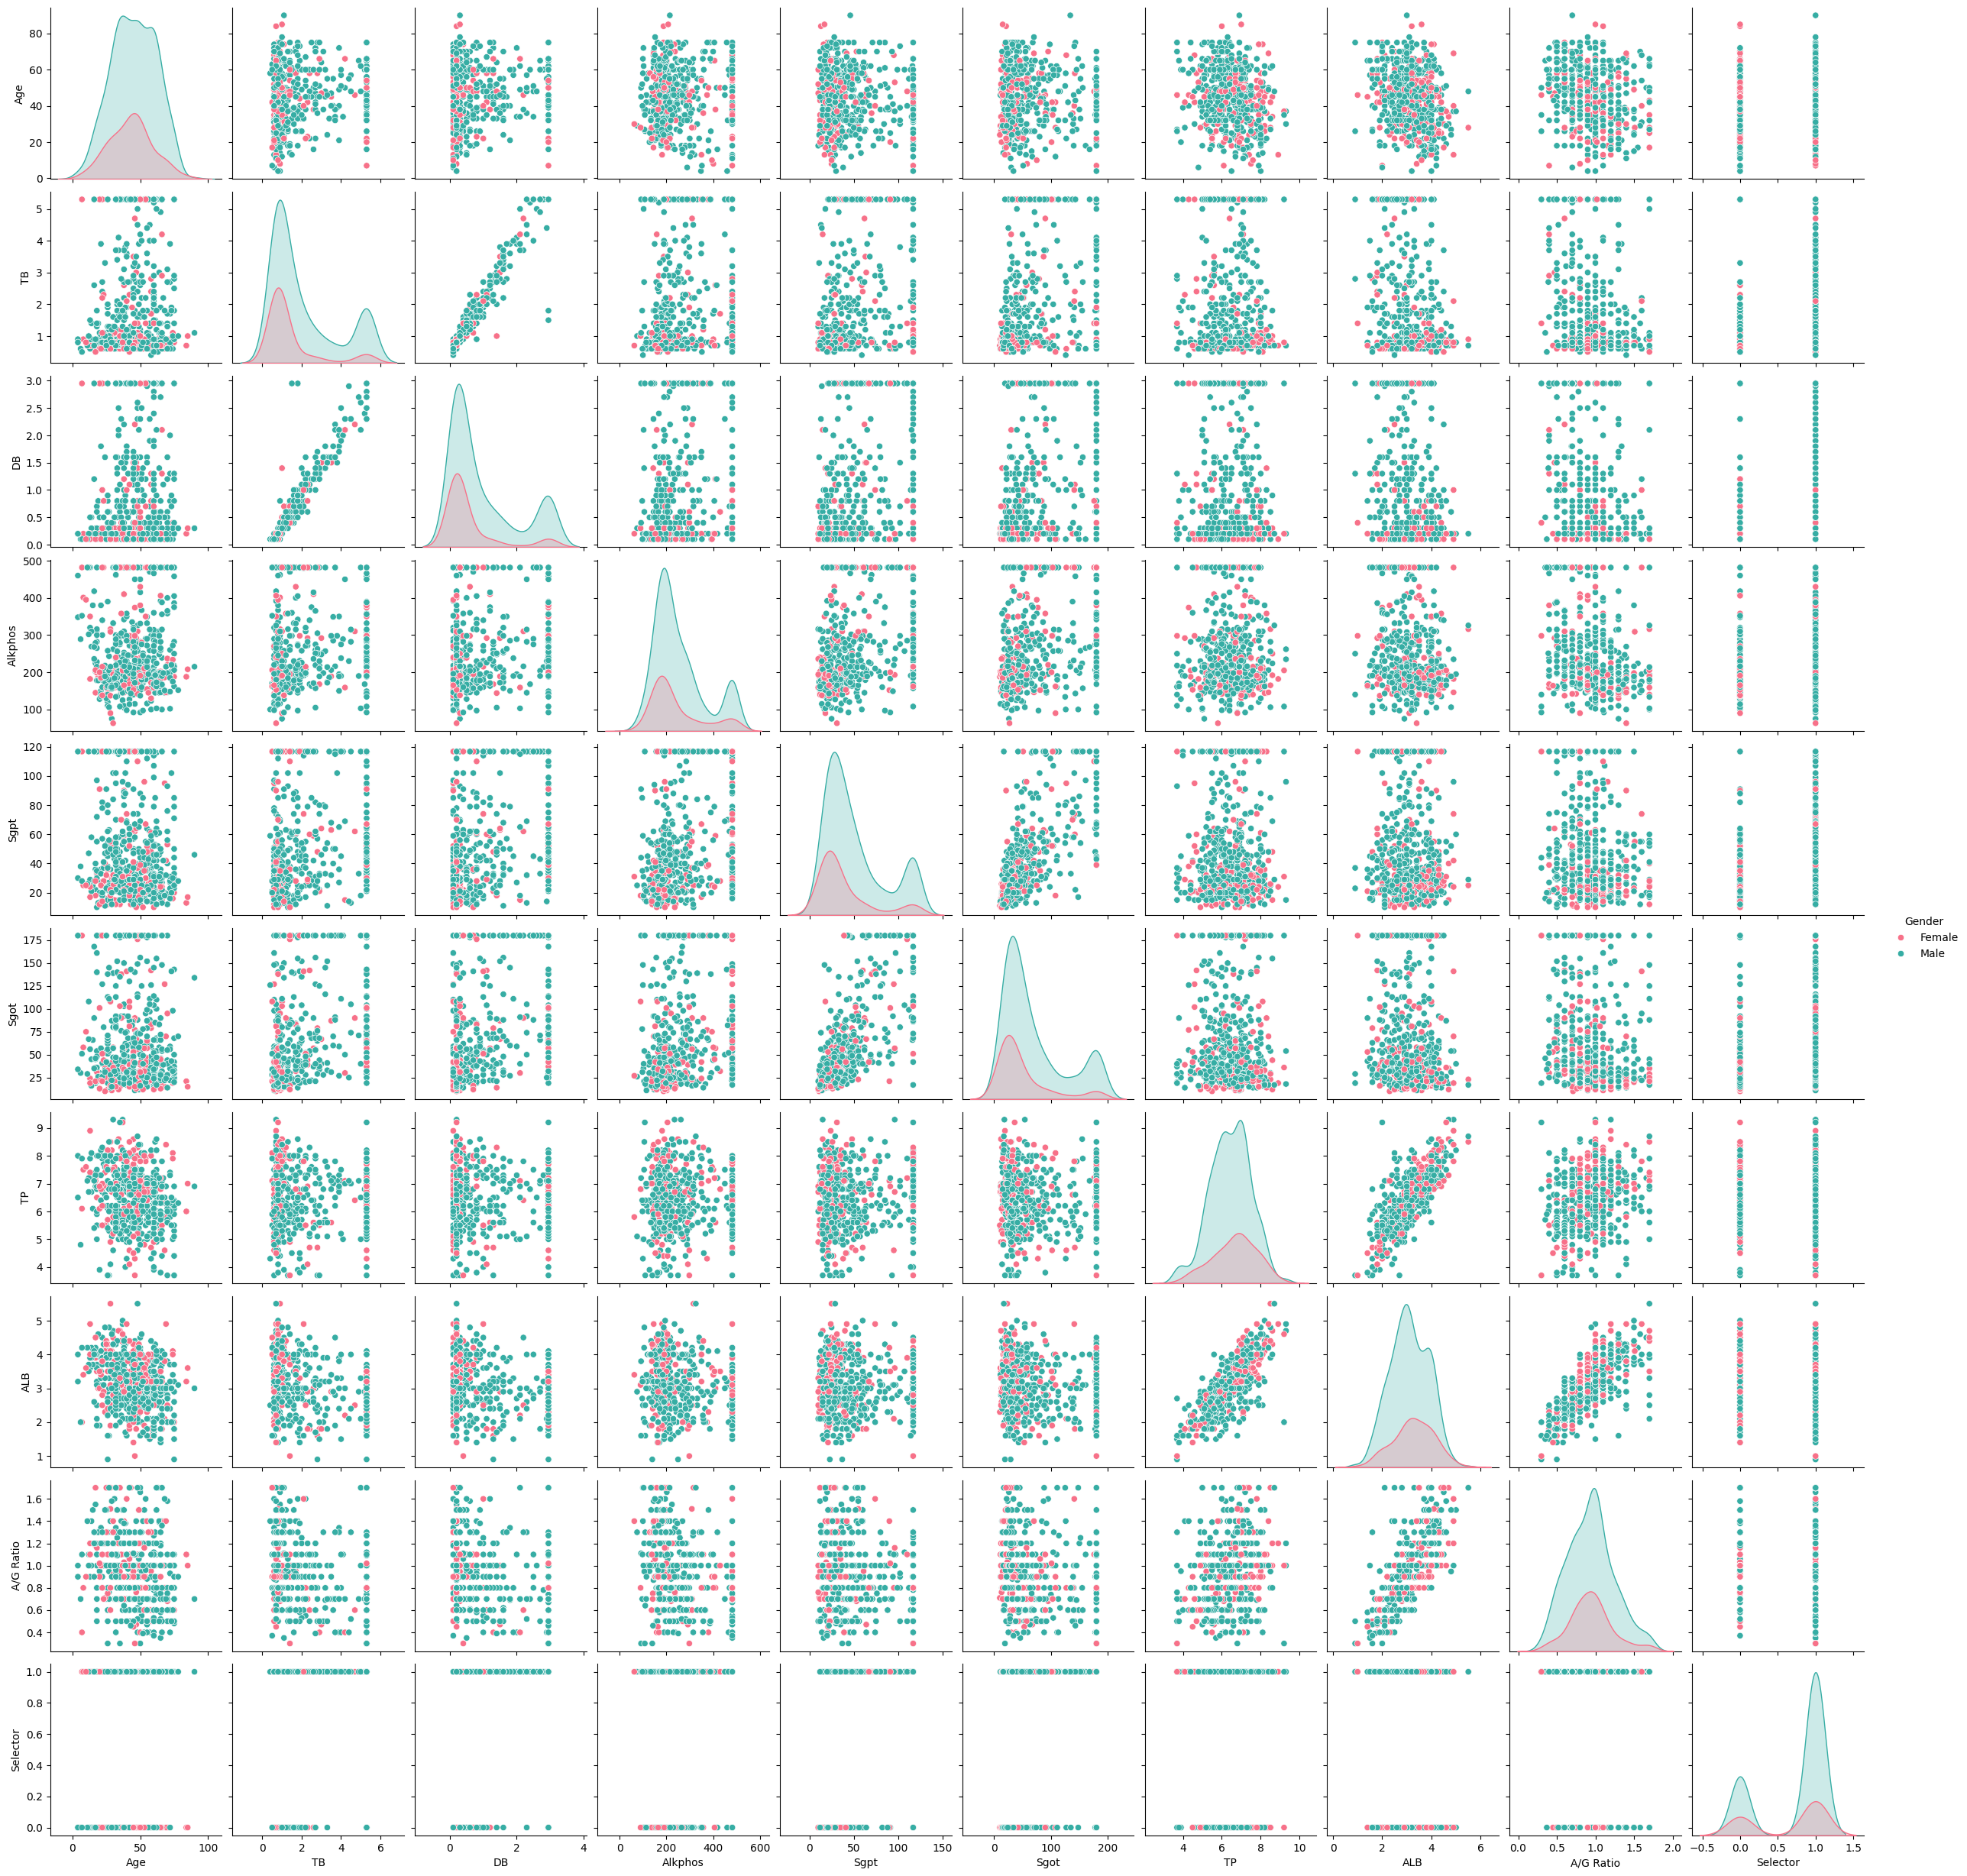

In [12]:
sns.pairplot(dataset,hue='Gender',diag_kind='kde',kind='scatter',palette='husl')
plt.show()

In [13]:
# The paiplot shows TB and DB, TP and ALB are correlated each other.
# If the graph represented in linear line, the variables are correlated each other. 

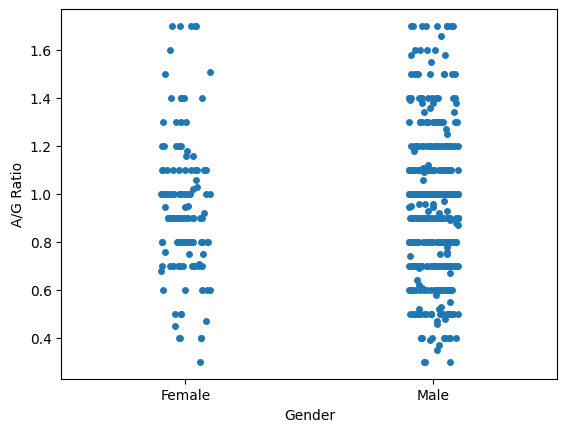

In [14]:
sns.stripplot(x='Gender',y='A/G Ratio',data=dataset)
plt.show()

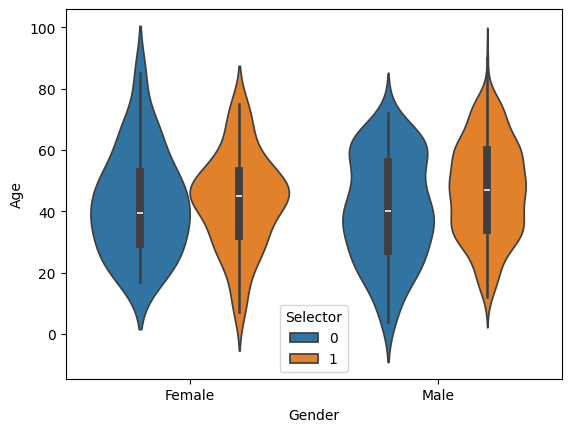

In [17]:
sns.violinplot(x='Gender',y='Age',data=dataset,hue='Selector')
plt.show()

In [16]:
# In the viloin graph, the density of the curve shows most of affected person between the range of Age.
# The affected female's age beween the range is 40 to 50 and the male's age between 35 to 60.

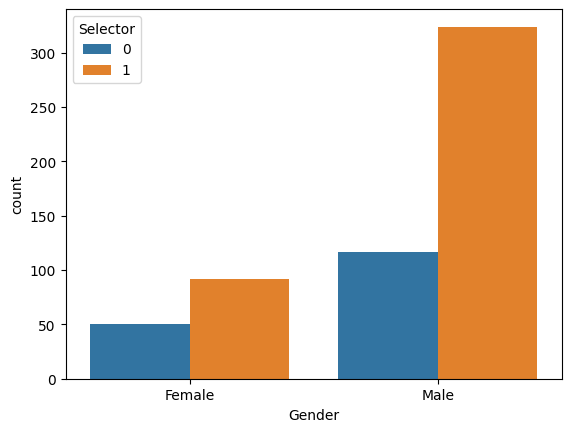

In [22]:
sns.countplot(x='Gender',data=dataset,hue='Selector')
plt.show()

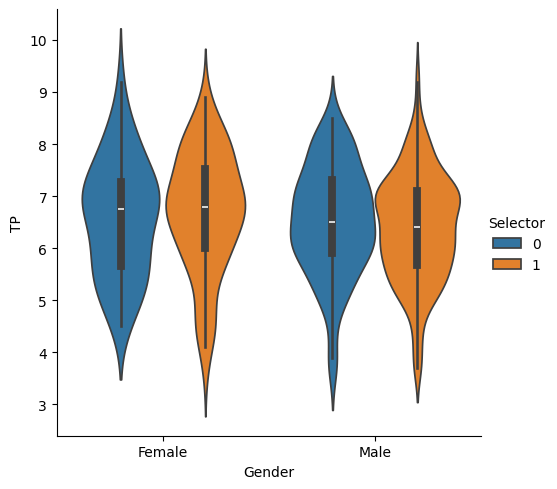

In [27]:
sns.catplot(x='Gender',y='TP',hue='Selector',kind='violin',data=dataset)
plt.show()

In [45]:
liver_disorder=dataset.groupby('Gender')['ALB'].value_counts().reset_index()
liver_disorder.head(10)

,Gender,ALB,count
0,Female,3.0,9
1,Female,3.1,9
2,Female,3.5,9
3,Female,2.5,8
4,Female,2.9,8
5,Female,4.0,8
6,Female,3.9,7
7,Female,3.2,6
8,Female,3.3,6
9,Female,3.6,6


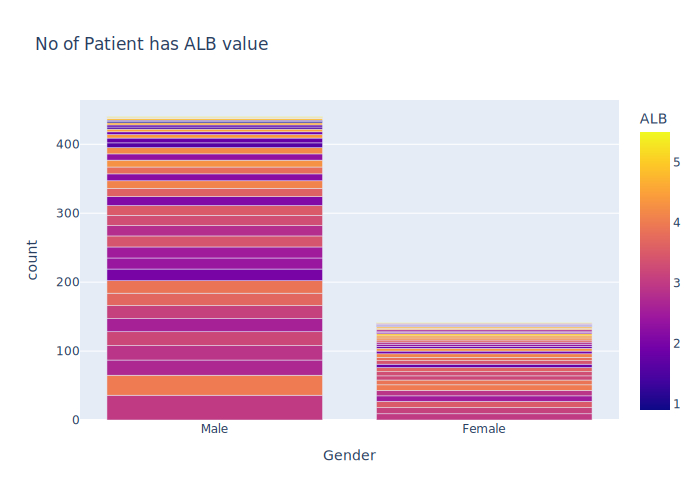

In [66]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default="svg"

fig=px.bar(liver_disorder,x='Gender',y='count',color='ALB',title='No of Patient has ALB value').update_xaxes(categoryorder='total descending')
fig.show()